## Analysis: 

**Purpose**: Identify a suitable risk proxy for construction projects

### Question / Hypothesis

**Origin**: Based on the goal of identifying a suitable risk proxy for construction projects 

**Question**: What is the impact of each project and what are the features needed to determine project duration and potential for extension?

**Assumptions**:
- **Data**: Miami-Dade FDOT Work Program (post-ingestion: LOC_ERROR == "NO ERROR")
- **Fiscal years**: [e.g., 2024–2029 or subset]
- **Features under test**: `Shape__Length` (normalized), `WPPHAZTP` (phase type → weights), optional spatial density.
- **Other**: [Any filtering or subsetting]

### Data Loading

In [13]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

DATA_PROCESSED = Path.cwd().parent / "src" / "data" / "processed"

construction_gdf = gpd.read_file(DATA_PROCESSED / "fdot_work_program_construction.gpkg")    
print(f"Loaded layers from: {construction_gdf}")


Loaded layers from:       OBJECTID  WPITEM WPITMSEG   ITMSEG      FINPROJ  RDWYLOC  BEGSECPT  \
0        36433  251688        1  2516881  25168815202       14     0.000   
1        36443  251688        1  2516881  25168815201       10    12.280   
2        36449  251688        1  2516881  25168815202        5     0.000   
3        36455  251688        1  2516881  25168815201       13    11.684   
4        36472  251688        1  2516881  25168815202       14     0.000   
...        ...     ...      ...      ...          ...      ...       ...   
6937    392658  456947        1  4569471  45694715401        3     0.000   
6938    393074  456947        1  4569471  45694715401        3     0.000   
6939    393166  456898        1  4568981  45689815401        2     2.264   
6940    393193  456972        1  4569721  45697215401        3     0.000   
6941    393320  456972        1  4569721  45697215401        3     0.000   

      ENDSECPT RDWYSIDE    RDWYID  ... FISCALYR PRPLCCDE PRPLCODE  

## Data Filtering & Preparation

Apply any subsetting (e.g., fiscal year, phase type). Check schema, missingness, duplicates, geometry. See [Data Dictionary](../README.md#data-dictionary).

In [14]:
# Count total rows in construction_gdf
print(f"Total rows in construction_gdf: {construction_gdf.shape}")

# Display unique fiscal years
print(construction_gdf["FISCALYR"].unique())


Total rows in construction_gdf: (6942, 28)
[2025 2023 2026 2024 2027 2028 2030 2029]


In [15]:
# Work mix codes and names (unique pairs)
work_mix_ref = (
    construction_gdf[["WPWKMIX", "WPWKMIXN"]]
    .drop_duplicates(subset=["WPWKMIX", "WPWKMIXN"])
    .sort_values(["WPWKMIX", "WPWKMIXN"])
)
display(work_mix_ref)


,WPWKMIX,WPWKMIXN
7,0002,NEW ROAD CONSTRUCTIO
973,0005,FLEXIBLE PAVEMENT RE
1811,0010,TRAFFIC OPS IMPROVEM
800,0012,RESURFACING
1826,0015,RESURFACING - RIDE O
714,0022,BRIDGE REPLACEMENT
0,0023,BRIDGE-REPLACE AND A
2133,0024,BRIDGE-REPAIR/REHABI
1990,0106,BIKE PATH/TRAIL
4999,0107,BIKE LANE/SIDEWALK


In [16]:
# Unique phase types (WPPHAZTP)
phase_types = construction_gdf["WPPHAZTP"].unique()
phase_types_table = pd.DataFrame(phase_types, columns=["WPPHAZTP"])
phase_types_table.sort_values(by="WPPHAZTP", ascending=True, inplace=True)
display(phase_types_table)

# Per phase type: mode of illustrative text fields
construction_gdf.groupby("WPPHAZTP")[[
    "WPITSTNM",
    "WPWKMIXN",
    "LOCALFULL",
]].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)


,WPPHAZTP
0,2
4,3
6,4
1,6
2,7
5,8
3,A


,WPITSTNM,WPWKMIXN,LOCALFULL
WPPHAZTP,,,
2,UNDER CONSTRUCTION,RESURFACING,SR 836/I-395 FROM WEST OF I-95 TO MACARTHUR CS...
3,UNDER CONSTRUCTION,ADD LANES & RECONSTR,SR 826/PALMETTO EXPRESSWAY FROM SOUTH OF NW 36...
4,CONTRACT EXECUTED,PEDESTRIAN SAFETY IM,CITY OF MIAMI BEACH- SOUTH BEACH PEDESTRIANPRI...
6,UNDER CONSTRUCTION,ADD LANES & RECONSTR,GOLDEN GLADES INTERCHANGE IMPROVEMENTS - SPUR
7,UNDER CONSTRUCTION,ADD LANES & RECONSTR,SR 7 AND SR 9/GOLDEN GLADES INTERCHANGE VARIOU...
8,PRE-CONST.UNDERWAY,BIKE PATH/TRAIL,CITYWIDE SIDEWALK CONNECTIVITY PROJECT - PHASE I
A,CONST.COMPLETE,RESURFACING,GOLDEN GLADES INTERCHANGE IMPROVEMENTS (MAINLI...


Based on the phase type data, we are able to build a legend for each type based on the char code

In [17]:
phase_type_legend = {
    "2": "Active Construction",
    "3": "Active Construction",
    "4": "Contract Executed",
    "6": "Active Construction",
    "7": "Active Construction",
    "8": "Pre-Construction",
    "A": "Construction Completed",
}

# Coerce to str so numeric codes match legend keys
construction_gdf["WPPHAZTP_DESC"] = construction_gdf["WPPHAZTP"].astype(str).map(phase_type_legend)
_unmapped = construction_gdf.loc[construction_gdf["WPPHAZTP_DESC"].isna(), "WPPHAZTP"].unique()
if len(_unmapped):
    print("Warning: unmapped WPPHAZTP codes:", _unmapped)

construction_gdf[["WPPHAZTP", "WPPHAZTP_DESC"]].head()

,WPPHAZTP,WPPHAZTP_DESC
0,2,Active Construction
1,2,Active Construction
2,2,Active Construction
3,2,Active Construction
4,2,Active Construction


In [18]:
# Assign weights to each phase type (interpretable prior; tune with sensitivity analysis later)
phase_weights = {
    "Pre-Construction": 0.25,
    "Contract Executed": 0.5,
    "Active Construction": 1.0,
    "Construction Completed": 0.1,
}

# Length in [0, 1] by max — outlier-sensitive; consider robust scaling (e.g. quantile) if needed
_len = construction_gdf["Shape__Length"]
construction_gdf["Normalized_Length"] = _len / _len.max()

construction_gdf["PHASE_WEIGHT"] = construction_gdf["WPPHAZTP_DESC"].map(phase_weights)
_missing_pw = int(construction_gdf["PHASE_WEIGHT"].isna().sum())
if _missing_pw:
    print("Warning: rows with missing PHASE_WEIGHT:", _missing_pw)

display(construction_gdf[["WPPHAZTP_DESC", "PHASE_WEIGHT"]].head())
display(construction_gdf[["WPPHAZTP_DESC", "PHASE_WEIGHT"]].tail())
display(construction_gdf["PHASE_WEIGHT"].describe())


,WPPHAZTP_DESC,PHASE_WEIGHT
0,Active Construction,1.0
1,Active Construction,1.0
2,Active Construction,1.0
3,Active Construction,1.0
4,Active Construction,1.0


,WPPHAZTP_DESC,PHASE_WEIGHT
6937,Contract Executed,0.5
6938,Contract Executed,0.5
6939,Contract Executed,0.5
6940,Contract Executed,0.5
6941,Contract Executed,0.5


count    6942.000000
mean        0.878572
std         0.291813
min         0.100000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: PHASE_WEIGHT, dtype: float64

## Calculations

Compute `risk_proxy` after `Normalized_Length` and `PHASE_WEIGHT` exist. Align with README: normalized exposure × phase weight (add spatial density later if used).


In [19]:
# Risk proxy: normalized length × phase weight
construction_gdf["risk_proxy"] = (
    construction_gdf["Normalized_Length"] * construction_gdf["PHASE_WEIGHT"]
)

display(
    construction_gdf[
        [
            "WPPHAZTP_DESC",
            "WPWKMIXN",
            "Shape__Length",
            "Normalized_Length",
            "PHASE_WEIGHT",
            "risk_proxy",
        ]
    ].head()
)

display(construction_gdf.groupby("WPPHAZTP_DESC")["risk_proxy"].describe())

# Tabular export for modeling (drop geometry)
out_csv = DATA_PROCESSED / "construction_with_risk_proxy.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
# Save the dataframe to a csv file (includes risk proxy)
construction_gdf.drop(columns=["geometry"], errors="ignore").to_csv(out_csv, index=False)
print(f"Saved: {out_csv.resolve()}")


,WPPHAZTP_DESC,WPWKMIXN,Shape__Length,Normalized_Length,PHASE_WEIGHT,risk_proxy
0,Active Construction,BRIDGE-REPLACE AND A,115.922570,0.009674,1.0,0.009674
1,Active Construction,BRIDGE-REPLACE AND A,279.354608,0.023314,1.0,0.023314
2,Active Construction,BRIDGE-REPLACE AND A,170.858574,0.014259,1.0,0.014259
3,Active Construction,BRIDGE-REPLACE AND A,2177.798387,0.181751,1.0,0.181751
4,Active Construction,BRIDGE-REPLACE AND A,115.922570,0.009674,1.0,0.009674


,count,mean,std,min,25%,50%,75%,max
WPPHAZTP_DESC,,,,,,,,
Active Construction,5892.0,0.054701,0.092016,0.000132,0.008966,0.019444,0.055893,0.817638
Construction Completed,558.0,0.005767,0.009094,0.000055,0.000916,0.002168,0.006534,0.067936
Contract Executed,113.0,0.027628,0.052901,0.000066,0.002015,0.009948,0.034966,0.500000
Pre-Construction,379.0,0.009831,0.019302,0.000034,0.002046,0.004562,0.009738,0.250000


Saved: /home/trevor/repos/CAP_3764_2026_Spring_Team_1/src/data/processed/construction_with_risk_proxy.csv


### Risk proxy construction

`risk_proxy = Normalized_Length × PHASE_WEIGHT`

- **`Normalized_Length`**: `Shape__Length / max(Shape__Length)` in this notebook (simple; outliers can dominate the divisor).
- **`PHASE_WEIGHT`**: prior weights from `WPPHAZTP` / `WPPHAZTP_DESC`.

Run cells in order: phase legend → weights/normalization → **Calculations** (`risk_proxy` + CSV).

## Test

Evaluate the hypothesis. EDA checklist (README): feature variance, non-pathological distributions, correlated structure, interpretability.

In [20]:
# EDA Questions
# Check the distribution of fiscal years
display(construction_gdf["FISCALYR"].value_counts().sort_index())   
# Risk by Phase Type
display(construction_gdf.groupby("WPPHAZTP_DESC")["risk_proxy"].mean().sort_values())
# Risk by Project Type
display(construction_gdf.groupby("WPWKMIXN")["risk_proxy"].mean().sort_values(ascending=False).head(10))

FISCALYR
2023    1332
2024    1391
2025    1380
2026    1596
2027     604
2028     313
2029     166
2030     160
Name: count, dtype: int64

WPPHAZTP_DESC
Construction Completed    0.005767
Pre-Construction          0.009831
Contract Executed         0.027628
Active Construction       0.054701
Name: risk_proxy, dtype: float64

WPWKMIXN
ADD SPECIAL USE LANE    0.247774
INTERCHANGE (NEW)       0.206551
ADD LANES & REHABILI    0.160180
LANDSCAPING             0.125335
LIGHTING                0.114292
MISCELLANEOUS CONSTR    0.094034
FLEXIBLE PAVEMENT RE    0.086367
ADD LANES & RECONSTR    0.084591
PAVEMENT ONLY RESURF    0.080158
RESURFACING - RIDE O    0.076239
Name: risk_proxy, dtype: float64

### Variance & distribution

Check variance (avoid near-zero), distribution shape (no single-feature dominance).

,Normalized_Length,PHASE_WEIGHT,risk_proxy
count,6942.000000,6942.000000,6942.000000
mean,0.054109,0.878572,0.047877
std,0.091478,0.291813,0.086752
min,0.000132,0.100000,0.000034
25%,0.008854,1.000000,0.006583
50%,0.019749,1.000000,0.016496
75%,0.055893,1.000000,0.047757
max,1.000000,1.000000,0.817638


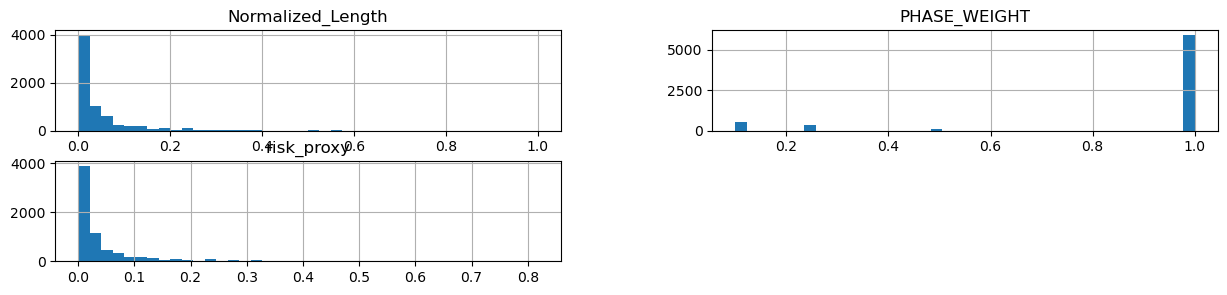

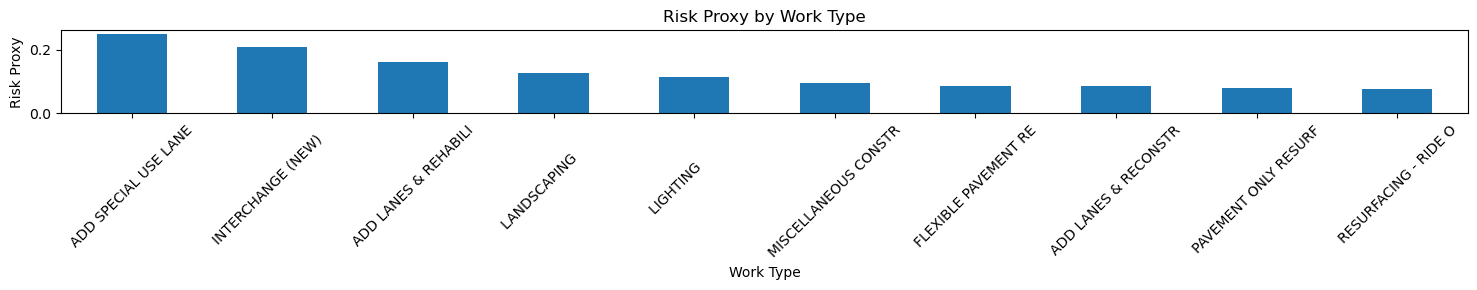

In [21]:
import matplotlib.pyplot as plt

# Core numeric distributions for the proxy
core = ["Normalized_Length", "PHASE_WEIGHT", "risk_proxy"]
core = [c for c in core if c in construction_gdf.columns]
display(construction_gdf[core].describe())
if core:
    construction_gdf[core].hist(bins=40, figsize=(15, 3))

# Risk Proxy by Work Type 
plt.figure(figsize=(15, 3))
work_risk = (
    construction_gdf.groupby("WPWKMIXN")["risk_proxy"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
work_risk.plot(kind="bar")
plt.xlabel("Work Type")
plt.ylabel("Risk Proxy")
plt.title("Risk Proxy by Work Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Correlations (multicollinearity)

Flag strong correlations (|r| > 0.8) between candidate features.

,Normalized_Length,PHASE_WEIGHT,risk_proxy,FISCALYR
Normalized_Length,1.000000,0.012690,0.938220,-0.042801
PHASE_WEIGHT,0.012690,1.000000,0.188412,-0.383077
risk_proxy,0.938220,0.188412,1.000000,-0.086306
FISCALYR,-0.042801,-0.383077,-0.086306,1.000000


(array([5.883e+03, 5.100e+02, 2.700e+02, 1.270e+02, 8.000e+01, 1.200e+01,
        4.000e+01, 5.000e+00, 7.000e+00, 8.000e+00]),
 array([3.35729969e-05, 8.17940624e-02, 1.63554552e-01, 2.45315041e-01,
        3.27075531e-01, 4.08836020e-01, 4.90596510e-01, 5.72356999e-01,
        6.54117488e-01, 7.35877978e-01, 8.17638467e-01]),
 <BarContainer object of 10 artists>)

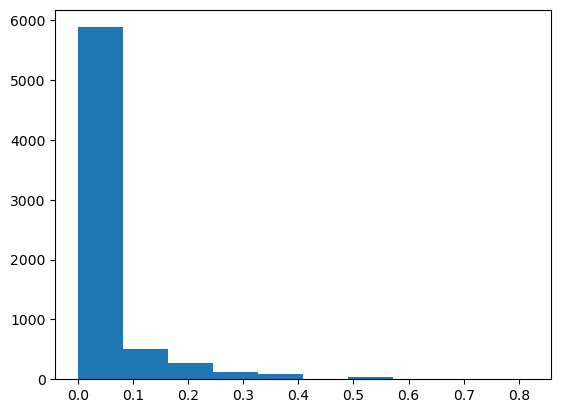

In [23]:
corr_cols = [c for c in ["Normalized_Length", "PHASE_WEIGHT", "risk_proxy", "FISCALYR"] if c in construction_gdf.columns]
if len(corr_cols) > 1:
    display(construction_gdf[corr_cols].corr())
plt.hist(construction_gdf["risk_proxy"])

### Geospatial (optional)

Map sample, bounds, or density visualization.

Text(0.5, 1.0, 'Sample segments (first 500)')

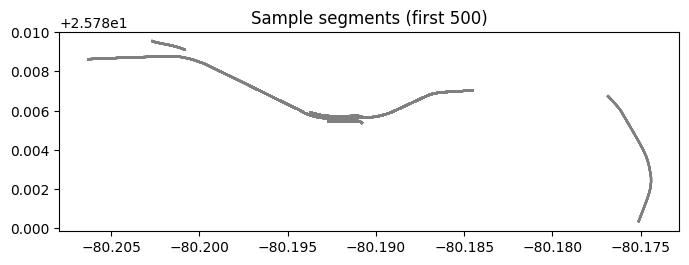

In [ ]:
ax = construction_gdf.head(500).plot(figsize=(8, 8), alpha=0.5, edgecolor="gray")
ax.set_title("Sample segments (first 500)")


## Findings

**Temporal Concentration**:
  - Project volume is concentrated between **2023-2026**, with fewer projects in later years, *likely planned future work*

**Construction Phase Impact**:
  - Active construction phases are associated with **higher operational impact**, as reflected in the elevated `risk_proxy` values relative to pre-construction stages (ex. "pre-construction", "contract exectuted")

**Work Type Impact**:
  - Infrastructure-intensive projects (ex. "Add Special Lane Use" ~25%, "Interchange" ~20%) show **signficantly** higher risk proxy scores compared to maintenance-oriented work (ex. "Landscaping" ~12%)

**Variance**: 
  - The `risk_proxy` variable shows **sufficient variability** to support downstream modeling, indicating that the feature reflects meaningful differences across project types.

**Distribution**: 
  - Temporal distribution is **right-skewed** with the fewest projects (rows) appearing in **2029** and **2030**

**Correlations**: 
  - Preliminary inspection suggests **potential multicollinearity** between "Normalized_Length" and our risk proxy variable (correlation ~0.94)

**Feature viability**: 
  - `risk_proxy` appears **supported** as a candidate predictor, and reflects both spatial and traffic-related dimensions of construction (impact)

## Summary
- These findings support the transition to a baseline modeling approach, where the predictive contribution of engineered and categorical features can be quantitatively evaluated.

## Next Steps

- Begin Baseline Model (OLS Regression)
- 1-Hot Encode categorical features
- Use baseline to compare against more advanced model